In [1]:
import os
os.environ["PYSPARK_PYTHON"] = 'python'
os.makedirs("Figures", exist_ok=True)
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans, GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator

In [2]:
spark = (
    SparkSession.builder.appName("SCOX_Disruption_Clustering")
    .config("spark.sql.session.timeZone", "UTC")
    .master("local[*]").getOrCreate()
)

In [3]:
disruption = spark.read.csv("Data\\FinalCSV\\clean_disruptiondata.csv", header=True, inferSchema=True)
timetable = spark.read.csv("Data\\FinalCSV\\clean_timetabledata.csv", header=True, inferSchema=True)

In [4]:
disruption = disruption.withColumn(
    "severity_score",
    when(col("Severity") == "verySlight", 1)
    .when(col("Severity") == "slight", 2)
    .when(col("Severity") == "normal", 3)
    .when(col("Severity") == "severe", 4)
    .when(col("Severity") == "verySevere", 5)
).withColumn("week_number", weekofyear(col("StartTime")))

disruption.createOrReplaceTempView("disruption")

In [5]:
query_features = """
SELECT
    LineRef AS line_code,
    week_number,
    COUNT(*) AS disruption_count,
    AVG(severity_score) AS avg_severity,
    AVG(DurationHours) AS avg_duration_hours,
    AVG(CASE WHEN Planned THEN 1 ELSE 0 END) AS pct_planned
FROM disruption
GROUP BY LineRef, week_number
"""

In [7]:
lines_df = timetable.select("LineName").distinct().withColumnRenamed("LineName", "line_code")

In [6]:
disruption_features = spark.sql(query_features)

In [8]:
START_DATE = datetime(2026, 4, 1)
END_DATE = datetime(2026, 6, 30)
week_numbers = sorted(set(
    (START_DATE + timedelta(days=d)).isocalendar()[1]
    for d in range((END_DATE - START_DATE).days + 1)
))

In [9]:
weeks_df = spark.createDataFrame([(w,) for w in week_numbers], ["week_number"])
full_grid = lines_df.crossJoin(weeks_df)
print("Full grid size:", full_grid.count())

Full grid size: 588


In [10]:
feature_table = full_grid.join(
    disruption_features, on=["line_code", "week_number"], how="left"
).fillna({
    "disruption_count": 0, "avg_severity": 0.0,
    "avg_duration_hours": 0.0, "pct_planned": 0.0
})

In [11]:
feature_table = feature_table.withColumn(
    "log_avg_duration_hours", log1p(col("avg_duration_hours"))
)

In [12]:
feature_table.toPandas().to_csv("Data\\FinalCSV\\clustering_features.csv", index=False)
print("Saved: Data\\FinalCSV\\clustering_features.csv")

Saved: Data\FinalCSV\clustering_features.csv


In [14]:
#three clustering models
df = spark.read.csv("Data\\FinalCSV\\clustering_features.csv", header=True, inferSchema=True)
print("Before filter:", df.count())

Before filter: 588


In [15]:
df = df.filter(col("disruption_count") > 0)
print("After filter (real signal only):", df.count())

After filter (real signal only): 157


In [16]:
FEATURE_COLS = ["disruption_count", "avg_severity", "log_avg_duration_hours", "pct_planned"]
assembler_raw = VectorAssembler(inputCols=FEATURE_COLS, outputCol="features_raw")
df_raw = assembler_raw.transform(df)

In [17]:
#baseline model (KMeans)
kmeans_baseline = KMeans(featuresCol="features_raw", predictionCol="cluster_baseline", k=3, seed=42)
model_baseline = kmeans_baseline.fit(df_raw)
pred_baseline = model_baseline.transform(df_raw)
wcss_baseline = model_baseline.summary.trainingCost

scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=True, withStd=True)
scaler_model = scaler.fit(df_raw)
df_scaled = scaler_model.transform(df_raw)
pred_baseline_scaled = scaler_model.transform(pred_baseline)
evaluator_fair = ClusteringEvaluator(featuresCol="features_scaled", predictionCol="cluster_baseline", metricName="silhouette")
silhouette_baseline = evaluator_fair.evaluate(pred_baseline_scaled)
print(f"=== MODEL 1: KMeans (Baseline, Unscaled) === Silhouette: {silhouette_baseline:.4f} | WCSS: {wcss_baseline:.4f}")
pred_baseline.groupBy("cluster_baseline").count().orderBy("cluster_baseline").show()

=== MODEL 1: KMeans (Baseline, Unscaled) === Silhouette: 0.3559 | WCSS: 155.2788
+----------------+-----+
|cluster_baseline|count|
+----------------+-----+
|               0|   31|
|               1|   82|
|               2|   44|
+----------------+-----+



In [18]:
#model 2 DBSCAN
features_pd = df_scaled.select("line_code", "week_number", "features_scaled").toPandas()
X = np.array(features_pd["features_scaled"].tolist())

dbscan = DBSCAN(eps=1.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)
features_pd["cluster_dbscan"] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
non_noise_mask = dbscan_labels != -1
silhouette_dbscan = silhouette_score(X[non_noise_mask], dbscan_labels[non_noise_mask]) if len(set(dbscan_labels[non_noise_mask])) > 1 else None
print(f"\n=== MODEL 2: DBSCAN (Advanced, Density) === Clusters: {n_clusters_dbscan} | Noise: {n_noise} | Silhouette: {silhouette_dbscan:.4f}")
print(features_pd["cluster_dbscan"].value_counts())


=== MODEL 2: DBSCAN (Advanced, Density) === Clusters: 3 | Noise: 19 | Silhouette: 0.3934
cluster_dbscan
 1    70
 0    57
-1    19
 2    11
Name: count, dtype: int64


In [19]:
# Model 3 gaussian misture model
gmm = GaussianMixture(featuresCol="features_scaled", predictionCol="cluster_gmm", k=3, seed=42)
model_gmm = gmm.fit(df_scaled)
pred_gmm = model_gmm.transform(df_scaled)
evaluator_gmm = ClusteringEvaluator(featuresCol="features_scaled", predictionCol="cluster_gmm", metricName="silhouette")
silhouette_gmm = evaluator_gmm.evaluate(pred_gmm)
print(f"\n=== MODEL 3: GMM (Advanced, Probabilistic) === Silhouette: {silhouette_gmm:.4f}")
pred_gmm.groupBy("cluster_gmm").count().orderBy("cluster_gmm").show()
comparison = pd.DataFrame({
    "Model": ["KMeans (Baseline, Unscaled)", "DBSCAN (Advanced, Density)", "GMM (Advanced, Probabilistic)"],
    "Type": ["Partition-based", "Density-based", "Model-based (EM)"],
    "Silhouette": [silhouette_baseline, silhouette_dbscan, silhouette_gmm],
    "N_Clusters": [3, n_clusters_dbscan, 3],
})
print("\n=== MODEL COMPARISON ===")
print(comparison)
comparison.to_csv("Data\\FinalCSV\\clustering_model_comparison.csv", index=False)


=== MODEL 3: GMM (Advanced, Probabilistic) === Silhouette: 0.5758
+-----------+-----+
|cluster_gmm|count|
+-----------+-----+
|          0|   52|
|          1|   75|
|          2|   30|
+-----------+-----+


=== MODEL COMPARISON ===
                           Model              Type  Silhouette  N_Clusters
0    KMeans (Baseline, Unscaled)   Partition-based    0.355935           3
1     DBSCAN (Advanced, Density)     Density-based    0.393361           3
2  GMM (Advanced, Probabilistic)  Model-based (EM)    0.575843           3


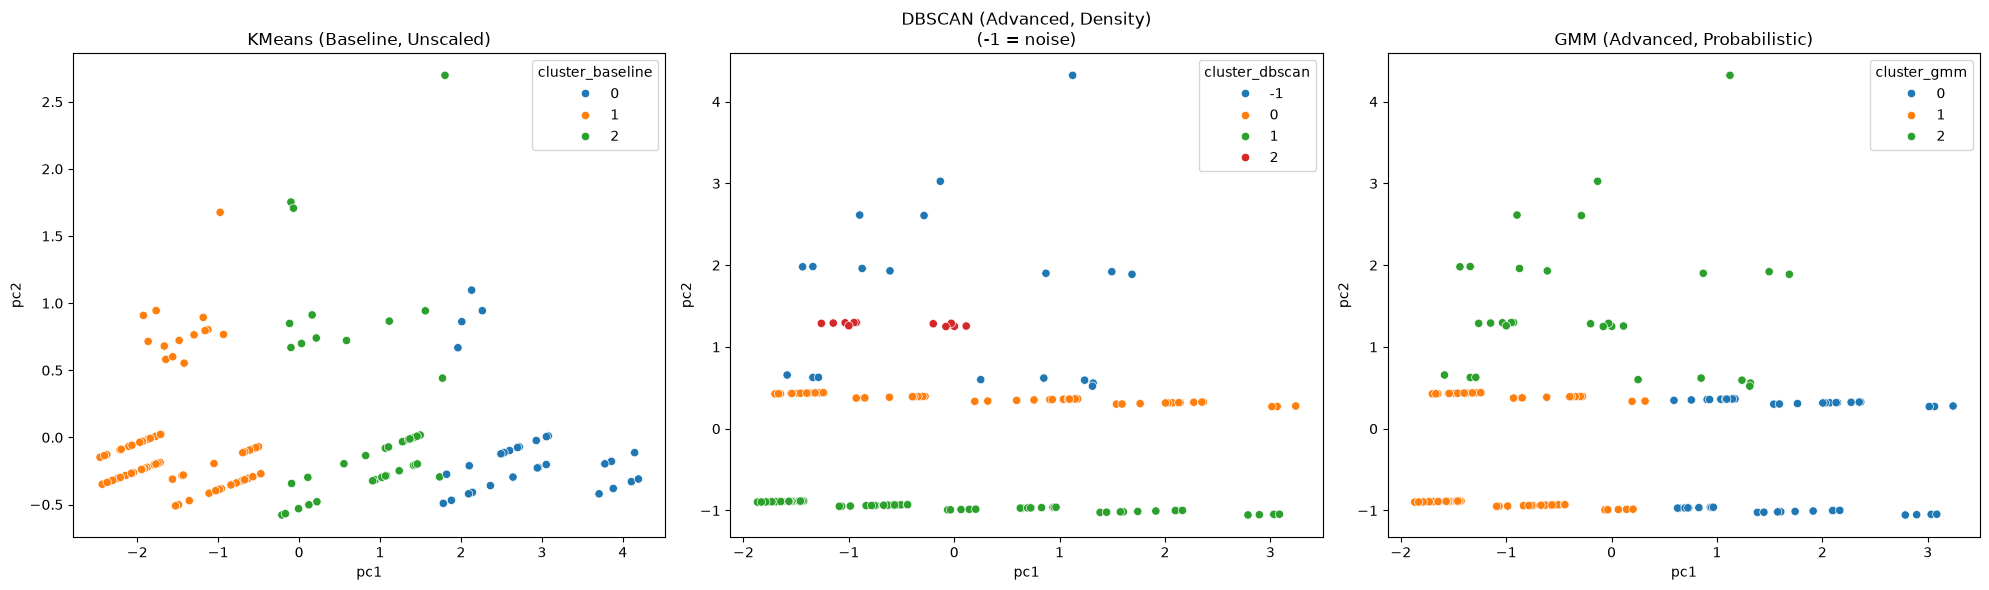

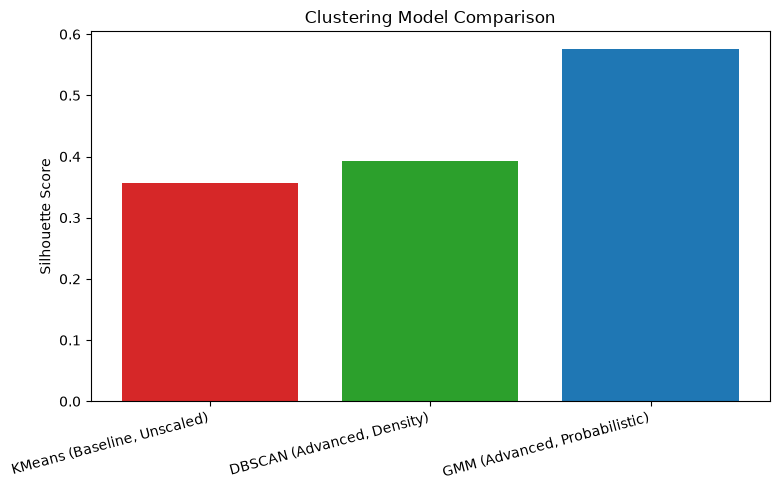

In [20]:
# visual ccomparison of 3 models
pred_baseline_pd = pred_baseline.select("line_code", "week_number", "features_raw", "cluster_baseline").toPandas()
pred_gmm_pd = pred_gmm.select("line_code", "week_number", "features_scaled", "cluster_gmm").toPandas()

def pca_2d(vector_col):
    return PCA(n_components=2, random_state=42).fit_transform(np.array(vector_col.tolist()))

bc = pca_2d(pred_baseline_pd["features_raw"]); pred_baseline_pd["pc1"], pred_baseline_pd["pc2"] = bc[:,0], bc[:,1]
dc = pca_2d(features_pd["features_scaled"]); features_pd["pc1"], features_pd["pc2"] = dc[:,0], dc[:,1]
gc = pca_2d(pred_gmm_pd["features_scaled"]); pred_gmm_pd["pc1"], pred_gmm_pd["pc2"] = gc[:,0], gc[:,1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.scatterplot(data=pred_baseline_pd, x="pc1", y="pc2", hue="cluster_baseline", palette="tab10", ax=axes[0])
axes[0].set_title("KMeans (Baseline, Unscaled)")
sns.scatterplot(data=features_pd, x="pc1", y="pc2", hue="cluster_dbscan", palette="tab10", ax=axes[1])
axes[1].set_title("DBSCAN (Advanced, Density)\n(-1 = noise)")
sns.scatterplot(data=pred_gmm_pd, x="pc1", y="pc2", hue="cluster_gmm", palette="tab10", ax=axes[2])
axes[2].set_title("GMM (Advanced, Probabilistic)")
plt.tight_layout()
plt.savefig("Figures/clustering_pca_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Silhouette"].fillna(0), color=["#d62728","#2ca02c","#1f77b4"])
plt.ylabel("Silhouette Score")
plt.title("Clustering Model Comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("Figures/clustering_silhouette_comparison.png", dpi=150, bbox_inches="tight")
plt.show()